In [2]:
!pip install simpy

In [3]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
def customer(env, server, service_rate, wait_times):
    arrival_time = env.now
    with server.request() as req:
        yield req
        wait_times.append(env.now - arrival_time)
        service_time = random.expovariate(service_rate)
        yield env.timeout(service_time)


In [5]:
def run_simulation(arrival_rate, service_rate, num_servers, sim_time=100):
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=num_servers)
    wait_times = []

    def arrival_process(env):
        while True:
            yield env.timeout(random.expovariate(arrival_rate))
            env.process(customer(env, server, service_rate, wait_times))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    if len(wait_times) == 0:
        return 0
    return np.mean(wait_times)


In [6]:
data = []

NUM_SIMULATIONS = 1000

for _ in range(NUM_SIMULATIONS):
    arrival_rate = np.random.uniform(0.2, 2.0)
    service_rate = np.random.uniform(0.5, 2.5)
    num_servers = np.random.randint(1, 6)

    avg_wait_time = run_simulation(
        arrival_rate, service_rate, num_servers
    )

    data.append([
        arrival_rate,
        service_rate,
        num_servers,
        avg_wait_time
    ])

df = pd.DataFrame(data, columns=[
    "arrival_rate", "service_rate", "num_servers", "avg_wait_time"
])

df.head()


,arrival_rate,service_rate,num_servers,avg_wait_time
0,1.306317,1.480055,1,1.638991
1,1.557895,2.433652,5,0.000000
2,1.256264,2.151007,2,0.029378
3,1.597323,0.513732,1,27.792170
4,1.893688,1.811150,5,0.003381


In [7]:
X = df.drop("avg_wait_time", axis=1)
y = df["avg_wait_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

In [9]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

In [13]:
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R2 Score"
])

results_df.sort_values("R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
4,Random Forest,0.628879,1.811422,0.886358
5,Gradient Boosting,0.860879,2.174932,0.836171
3,Decision Tree,0.758362,2.368074,0.805782
6,SVR,1.272306,4.252152,0.373794
0,Linear Regression,2.614960,4.485141,0.303290
1,Ridge Regression,2.612344,4.485750,0.303101
2,Lasso Regression,2.299559,5.059739,0.113342


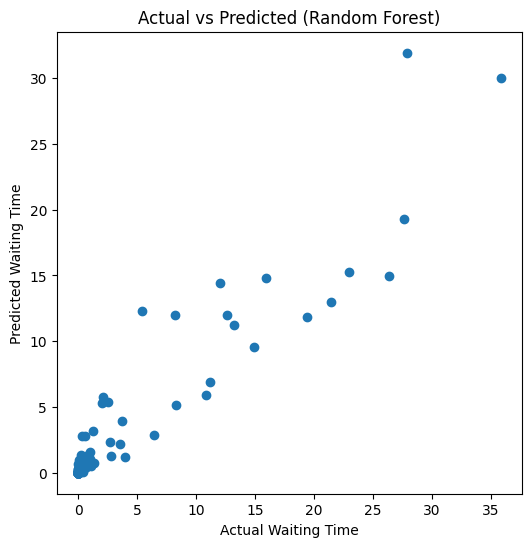

In [11]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Waiting Time")
plt.ylabel("Predicted Waiting Time")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


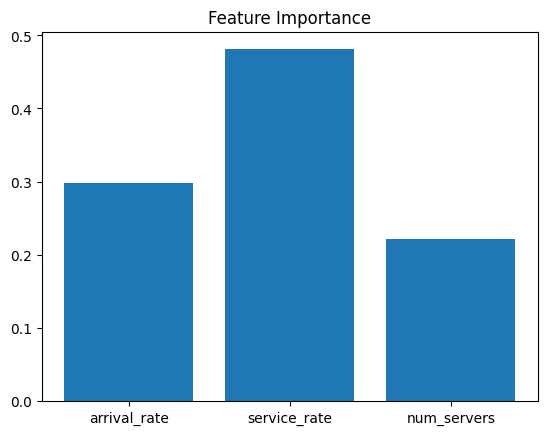

In [12]:
importances = best_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()
